In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('../data/f1_dataset.parquet')
sns.set(style="whitegrid")

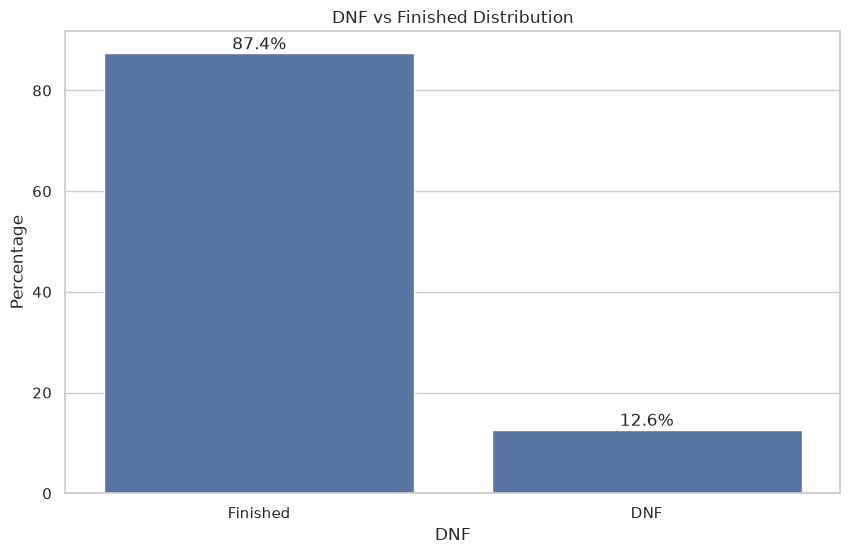

In [2]:
# Clarifying the class balance of the target variable DNF, we can use a countplot to visualize the distribution of the target variable DNF.
#  We can also use the stat='percent' parameter to show the percentage of each class in the plot.
dnf_mapping = {0: "Finished", 1: "DNF"}
plt.figure(figsize=(10, 6))

ax = sns.countplot(x=df['DNF'].map(dnf_mapping), stat='percent', data=df)


for container in ax.containers:
    ax.bar_label(container, fmt="{:.1f}%")


plt.title('DNF vs Finished Distribution')
plt.xlabel('DNF')
plt.ylabel('Percentage')

plt.savefig('../images/dnf_distribution.png', dpi=300, bbox_inches='tight')

# Looking at the plot above we can clearly see the distribution between DNF and Finish status, high finished rate versus low DNF rate

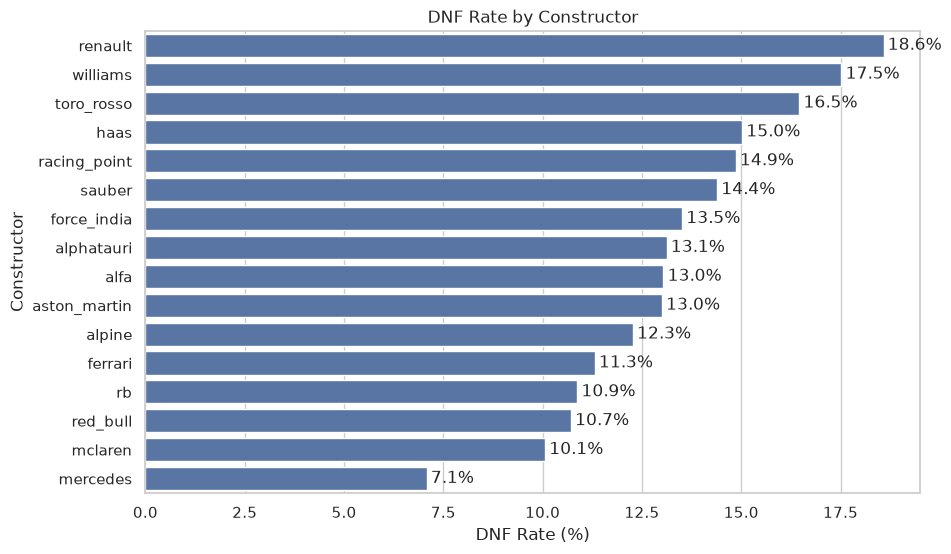

In [3]:
# Grouping teams by TeamId to extract the DNF rate by each team

team_group = df.groupby('TeamId')['DNF'].mean().sort_values(ascending=False).reset_index()
team_group['DNF %'] = round(team_group['DNF'] * 100, 2)
team_group = team_group.drop(columns=['DNF'])

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=team_group, y='TeamId', x='DNF %', orient='h')

for container in ax.containers:
    ax.bar_label(container, fmt='{:.1f}%', padding=3)

plt.title("DNF Rate by Constructor")
plt.xlabel("DNF Rate (%)")
plt.ylabel("Constructor")

plt.savefig('../images/dnf_rate_by_team.png', dpi=300, bbox_inches='tight')

# Above charts give us a clear vision of who's the team that need to maybe change the engineers or drivers to reduce DNFs (I hope this joke is funny)

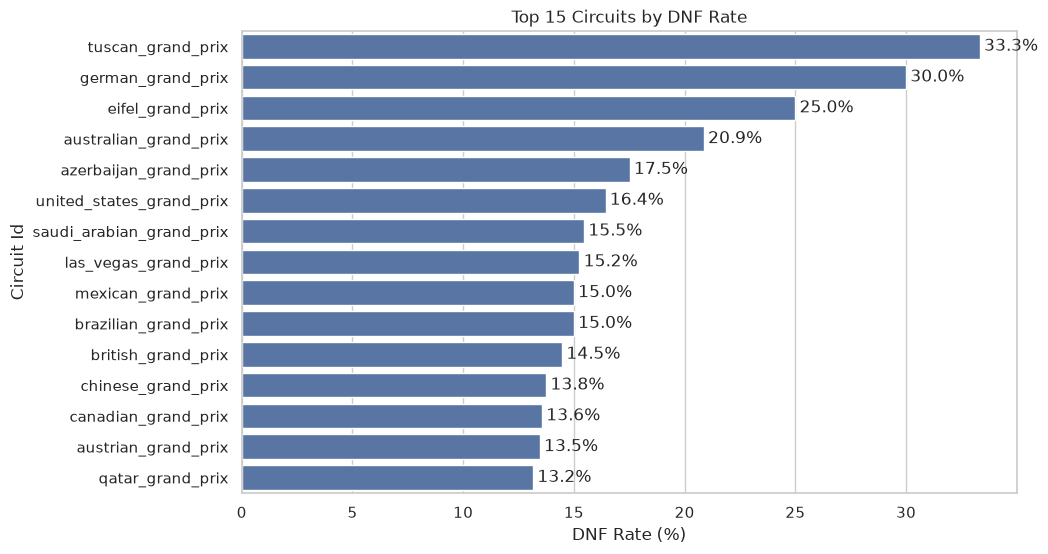

In [4]:
# Grouping by circuit id to extract the top 15 high rated circuit with DNFs

circuit_group = df.groupby('circuit_id')['DNF'].mean().sort_values(ascending=False).head(15).reset_index()
circuit_group['DNF %'] = round(circuit_group['DNF'] * 100, 2)
circuit_group = circuit_group.drop(columns=['DNF'])
circuit_group

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=circuit_group, y='circuit_id', x='DNF %', orient='h')

for container in ax.containers:
    ax.bar_label(container, fmt='{:.1f}%', padding=3)

plt.title("Top 15 Circuits by DNF Rate")
plt.ylabel("Circuit Id")
plt.xlabel("DNF Rate (%)")

plt.savefig('../images/top_15_circuits_by_dnf_rate.png', dpi=300, bbox_inches='tight')

# Above we can see the high ratd circuit that hold DNFs, tuscan is maybe a hard circuit or it is just a curse 

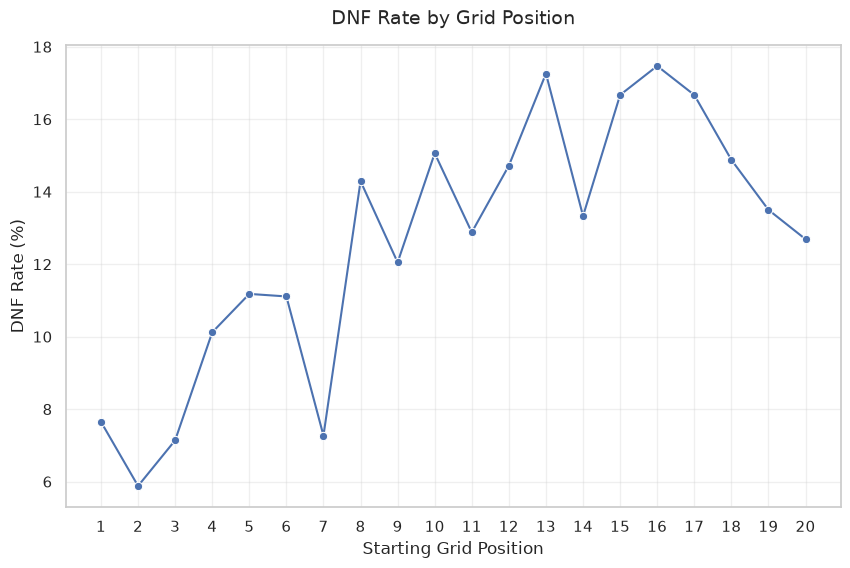

In [5]:
# Racing datasets (like F1) usually use 0 to indicate a pit lane start or an unclassified qualification 
# but We don't want a "0th" position showing up on a clean grid timeline.
df_filtered = df[df['GridPosition'] > 0]

# After filtering, We group by GridPosition to extract the high rated position with DNFs Using lineplot
grid_pos_group = df_filtered.groupby('GridPosition')['DNF'].mean().sort_values(ascending=False).reset_index()
grid_pos_group['DNF %'] = round(grid_pos_group['DNF'] * 100, 2)
grid_pos_group = grid_pos_group.drop(columns=['DNF'])

grid_pos_group = grid_pos_group.sort_values('GridPosition')

plt.figure(figsize=(10, 6))

sns.lineplot(data=grid_pos_group, x='GridPosition', y='DNF %', marker='o')

min_pos = int(grid_pos_group['GridPosition'].min())
max_pos = int(grid_pos_group['GridPosition'].max())

import numpy as np
plt.xticks(np.arange(min_pos, max_pos + 1, 1))


plt.title("DNF Rate by Grid Position", fontsize=14, pad=15)
plt.xlabel("Starting Grid Position")
plt.ylabel("DNF Rate (%)")
plt.grid(True, alpha=0.3)

plt.savefig('../images/dnf_rate_by_grid_position.png', dpi=300, bbox_inches='tight')

# the line plot above shows that starting in 13 ot 16 grid position is the high rated position where driver usually DNFs, it is understandable because of the traffic that drivers has to face

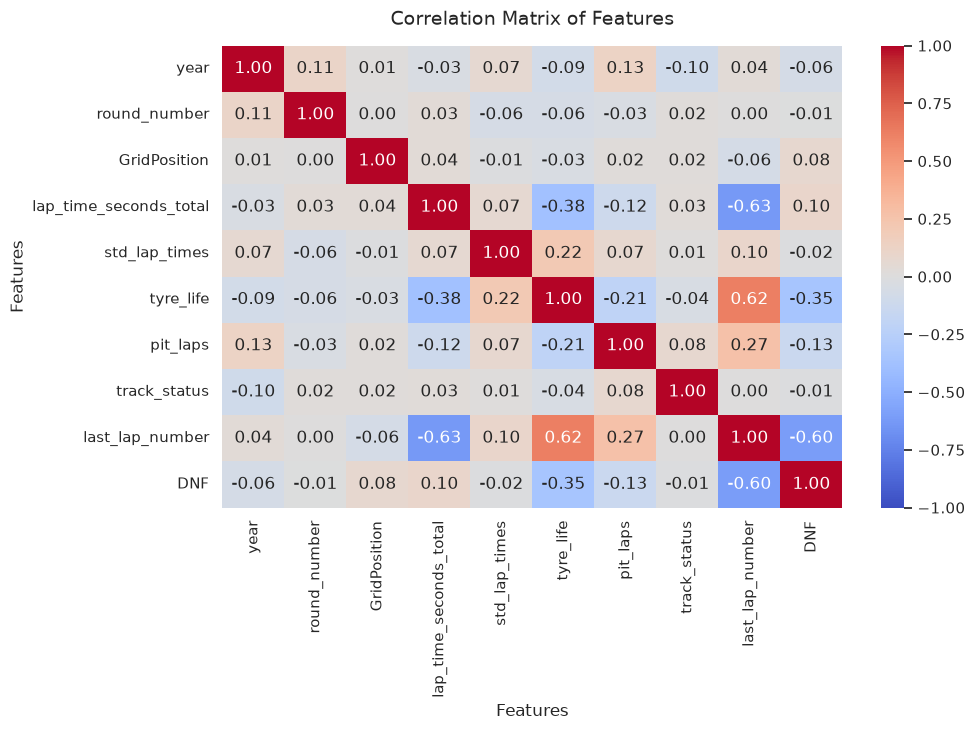

In [6]:
# plotting a Correlation Matrix to see which features move together
df_numeric = df.drop(columns=['DriverId', 'TeamId', 'circuit_id'])
correlation_heatmap = df_numeric.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(data=correlation_heatmap, annot=True, fmt='.2f', cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation Matrix of Features", fontsize=14, pad=15)
plt.xlabel("Features")
plt.ylabel("Features")

plt.savefig('../images/correlation_matrix.png', dpi=300, bbox_inches='tight')

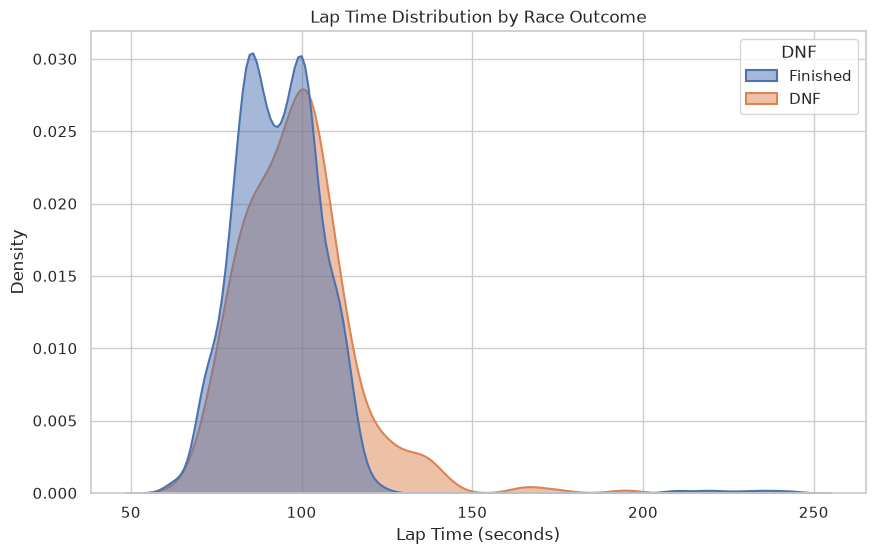

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='lap_time_seconds_total',hue=df['DNF'].map(dnf_mapping), fill=True, common_norm=False, alpha=0.5, linewidth=1.5)
plt.title('Lap Time Distribution by Race Outcome')
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Density')

plt.savefig('../images/lap_time_distribution_by_race_outcome.png', dpi=300, bbox_inches='tight')

# if f the curves overlap heavily — lap time alone doesn't separate finishers from DNF drivers well
# If the DNF curve is shifted left — DNF drivers had faster average laps, possibly because they retired early before traffic/fuel saving
# If the DNF curve is wider — DNF drivers had more inconsistent lap times